# 6. Ієрархічна кластеризація (Agglomerative)

Ієрархічна агломеративна кластеризація — алгоритм "знизу-вгору", що починає з кожної точки як окремого кластера і послідовно об'єднує найближчі кластери. Використовуємо метод Ward, який мінімізує внутрішньокластерну дисперсію.

In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from scipy.cluster.hierarchy import linkage
from src.config import *
from src.data_loader import create_scaled, subsample
from src.visualization import plot_cluster_scatter_2d, plot_silhouette_curve, plot_dendrogram
from src.evaluation import compute_metrics, find_best_k, build_results_row, save_results
from src.clustering import run_hierarchical, get_cluster_profiles

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv(PROCESSED_PATH)
with open(TOP_PAIRS_PATH) as f:
    pairs = json.load(f)
n_sample = SAMPLE_SIZES['hierarchical']
df_sub = subsample(df, n_sample)
print(f"Підвибірка: {len(df_sub)} записів")

Підвибірка: 10000 записів


## 6.1 Дендрограми

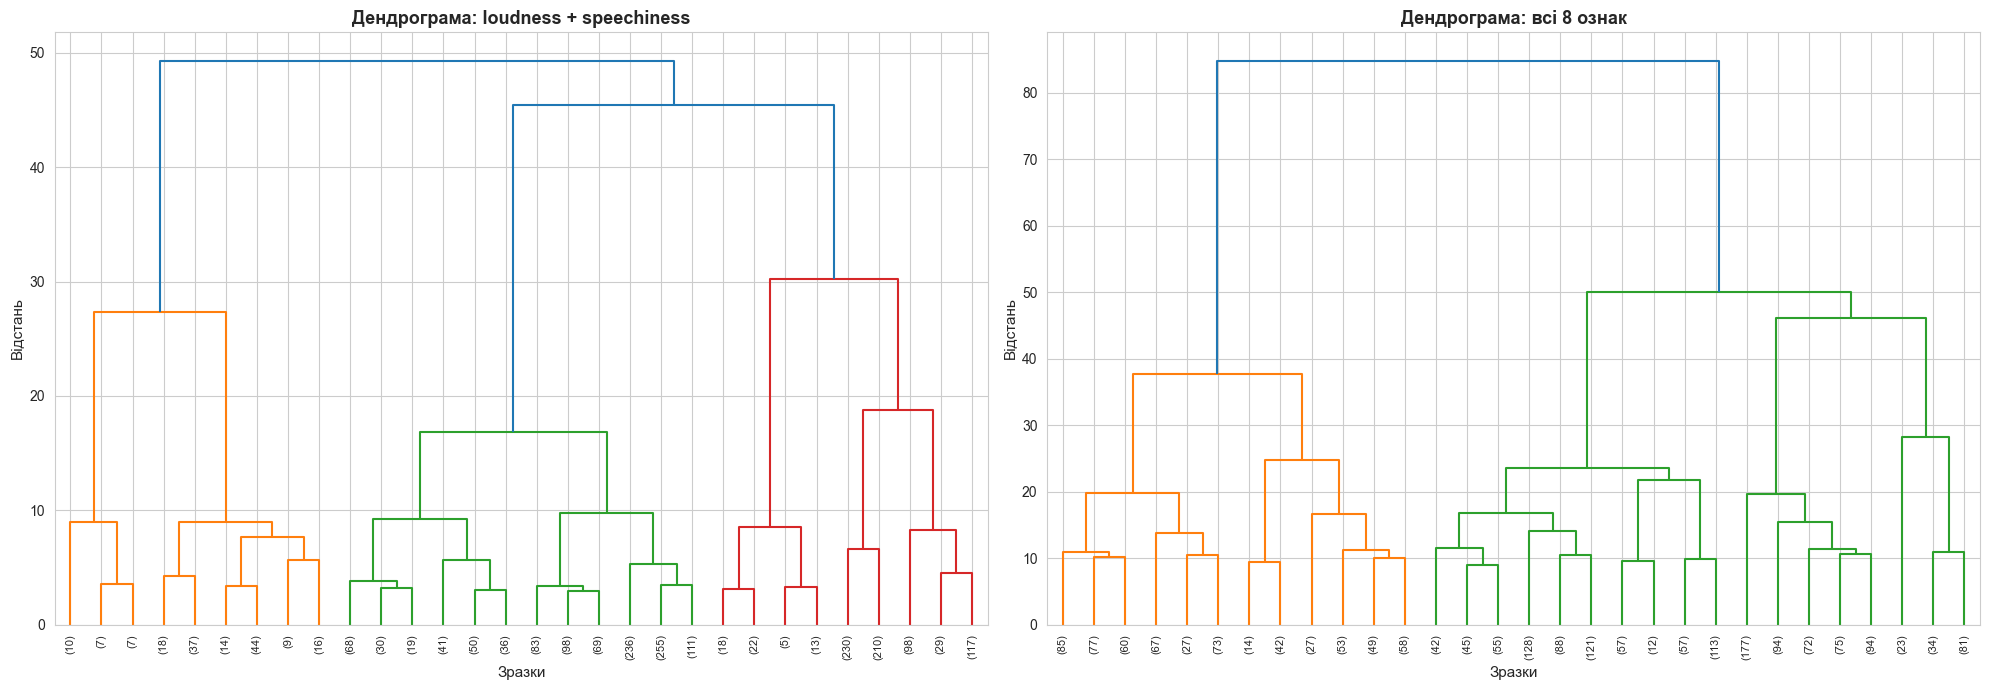

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Дендрограма для першої пари
X_pair0, _ = create_scaled(df_sub, pairs[0])
Z0 = linkage(X_pair0.values[:2000], method='ward')
plot_dendrogram(Z0, f'Дендрограма: {pairs[0][0]} + {pairs[0][1]}', ax=axes[0], truncate_p=30)

# Дендрограма для всіх 8 ознак
X_full_dendro, _ = create_scaled(df_sub, AUDIO_FEATURES)
Z_full = linkage(X_full_dendro.values[:2000], method='ward')
plot_dendrogram(Z_full, 'Дендрограма: всі 8 ознак', ax=axes[1], truncate_p=30)

plt.tight_layout()
plt.show()

## 6.2 Підбір оптимального k

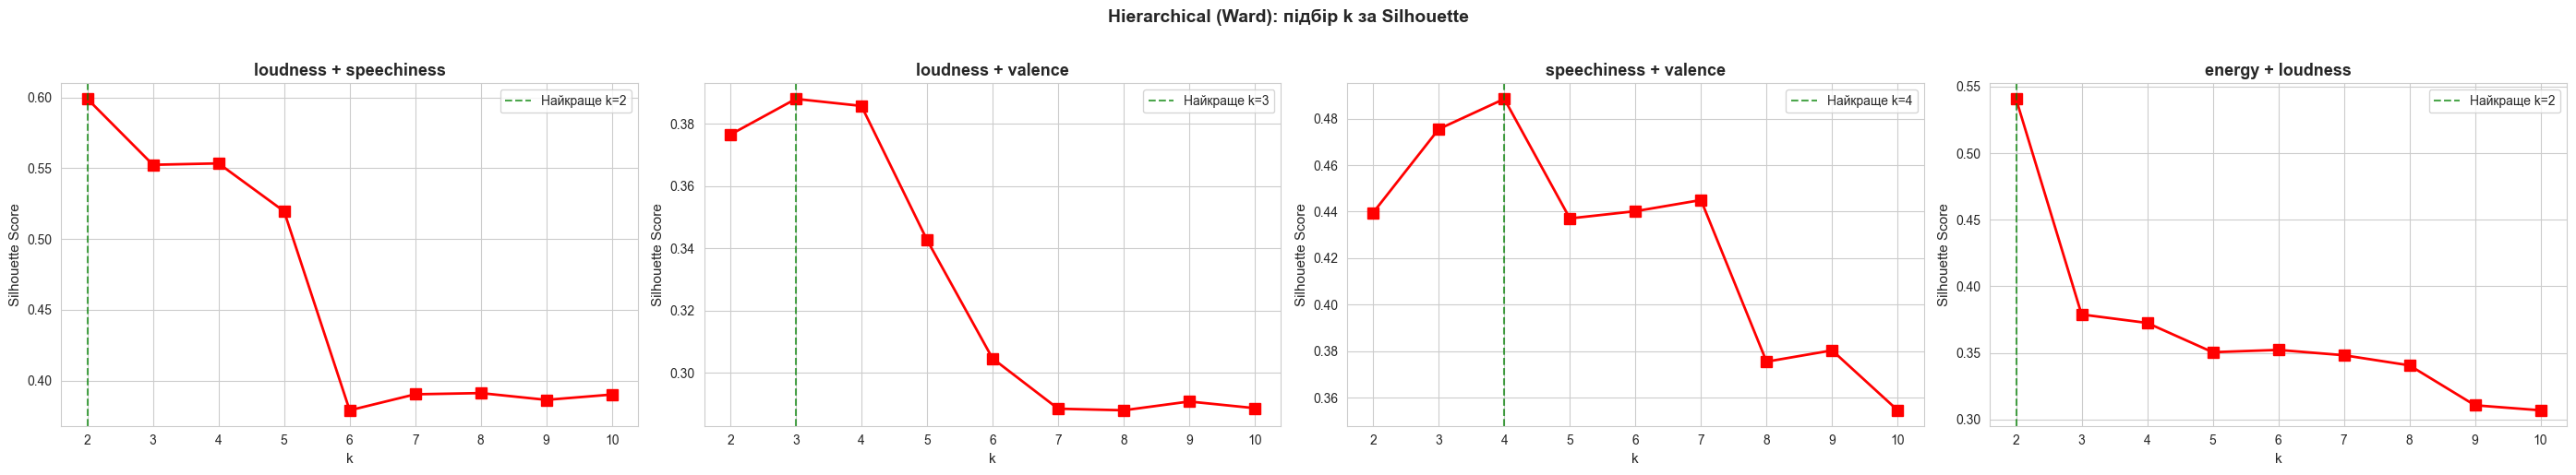

loudness + speechiness: найкращий k = 2
loudness + valence: найкращий k = 3
speechiness + valence: найкращий k = 4
energy + loudness: найкращий k = 2


In [4]:
best_k_pairs = {}

fig, axes = plt.subplots(1, len(pairs), figsize=(7 * len(pairs), 5))
if len(pairs) == 1:
    axes = [axes]

for j, pair in enumerate(pairs):
    X_pair, _ = create_scaled(df_sub, pair)
    best_k_val, scores = find_best_k(
        X_pair, K_RANGE,
        fit_fn=lambda X, k: run_hierarchical(X, k, linkage='ward')[0]
    )
    best_k_pairs[j] = best_k_val
    plot_silhouette_curve(K_RANGE, scores,
                          f'{pair[0]} + {pair[1]}', ax=axes[j])

plt.suptitle('Hierarchical (Ward): пiдбiр k за Silhouette',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for j, pair in enumerate(pairs):
    print(f"{pair[0]} + {pair[1]}: найкращий k = {best_k_pairs[j]}")

## 6.3 Кластеризація пар та 2D-візуалізація

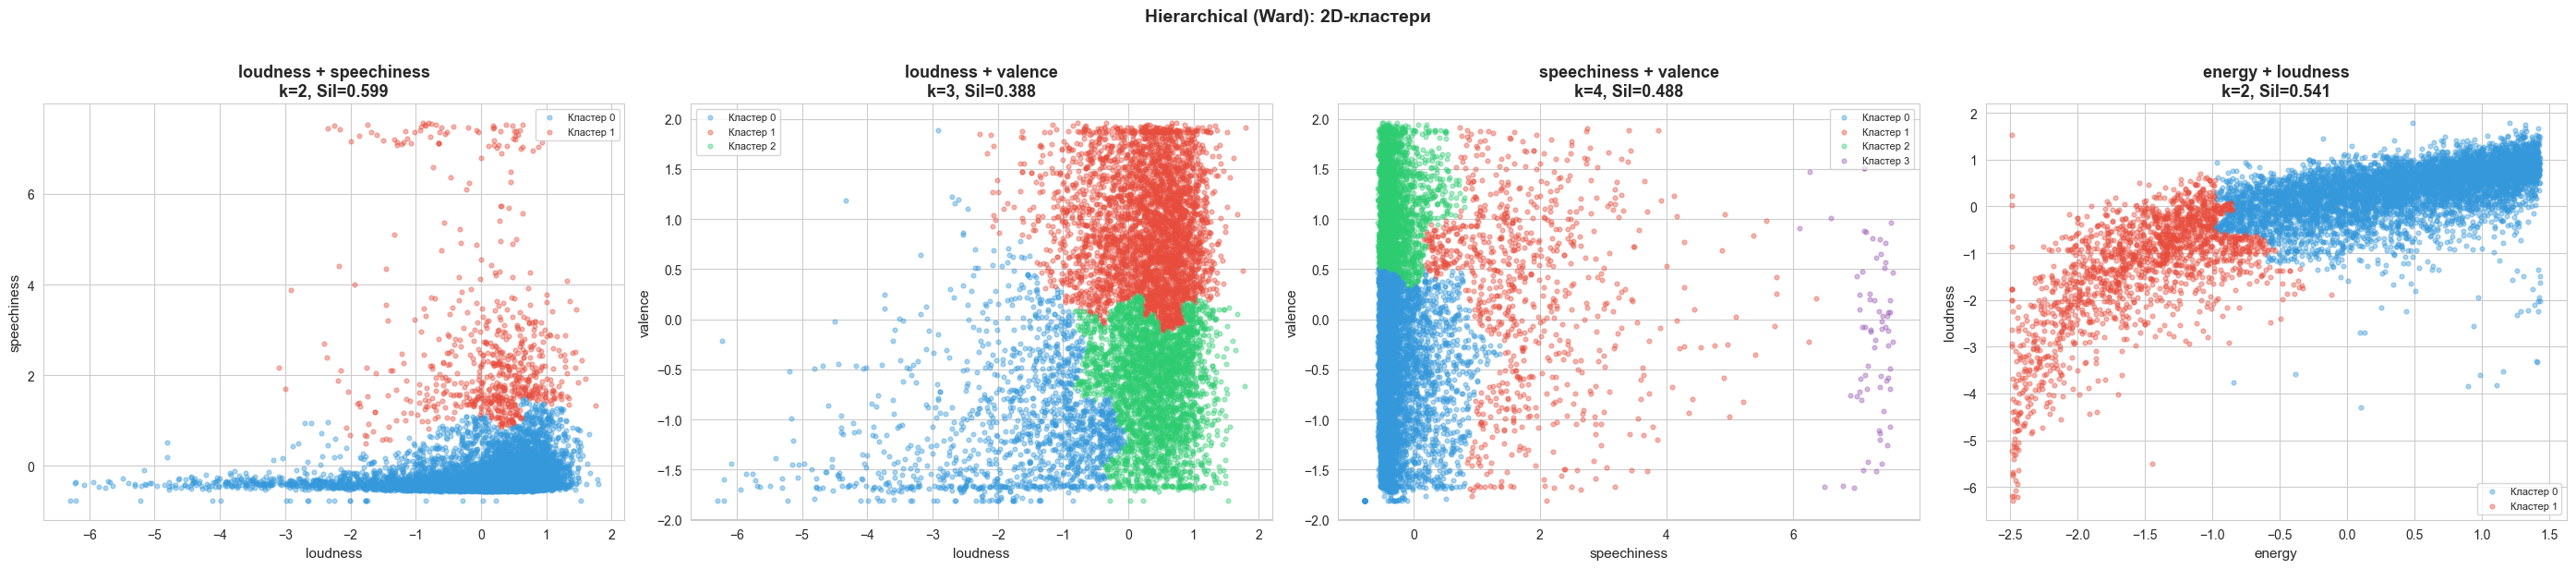

,algorithm,pair,k,silhouette,davies_bouldin,time_sec
0,Hierarchical,loudness + speechiness,2,0.598919,0.832792,2.3117
1,Hierarchical,loudness + valence,3,0.387955,0.850003,2.6147
2,Hierarchical,speechiness + valence,4,0.488456,0.680420,2.4842
3,Hierarchical,energy + loudness,2,0.540771,0.702690,2.8289


In [5]:
results = []
pair_labels = {}
n_pairs = len(pairs)
fig, axes = plt.subplots(1, n_pairs, figsize=(7 * n_pairs, 6))
if n_pairs == 1:
    axes = [axes]

for j, pair in enumerate(pairs):
    X_pair, _ = create_scaled(df_sub, pair)
    k = best_k_pairs[j]

    start = time.time()
    labels, _ = run_hierarchical(X_pair, k, linkage='ward')
    pair_labels[j] = labels
    elapsed = time.time() - start

    metrics = compute_metrics(X_pair, labels)
    pair_name = f"{pair[0]} + {pair[1]}"
    results.append(build_results_row('Hierarchical', pair_name, k, metrics, elapsed))

    plot_cluster_scatter_2d(
        X_pair, labels, pair,
        title=f'{pair_name}\nk={k}, Sil={metrics["silhouette"]:.3f}',
        ax=axes[j]
    )

plt.suptitle('Hierarchical (Ward): 2D-кластери', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

pd.DataFrame(results)

## 6.4 Жанровий склад кластерiв

Аналiз розподiлу музичних жанрiв мiж кластерами для кожної пари ознак.

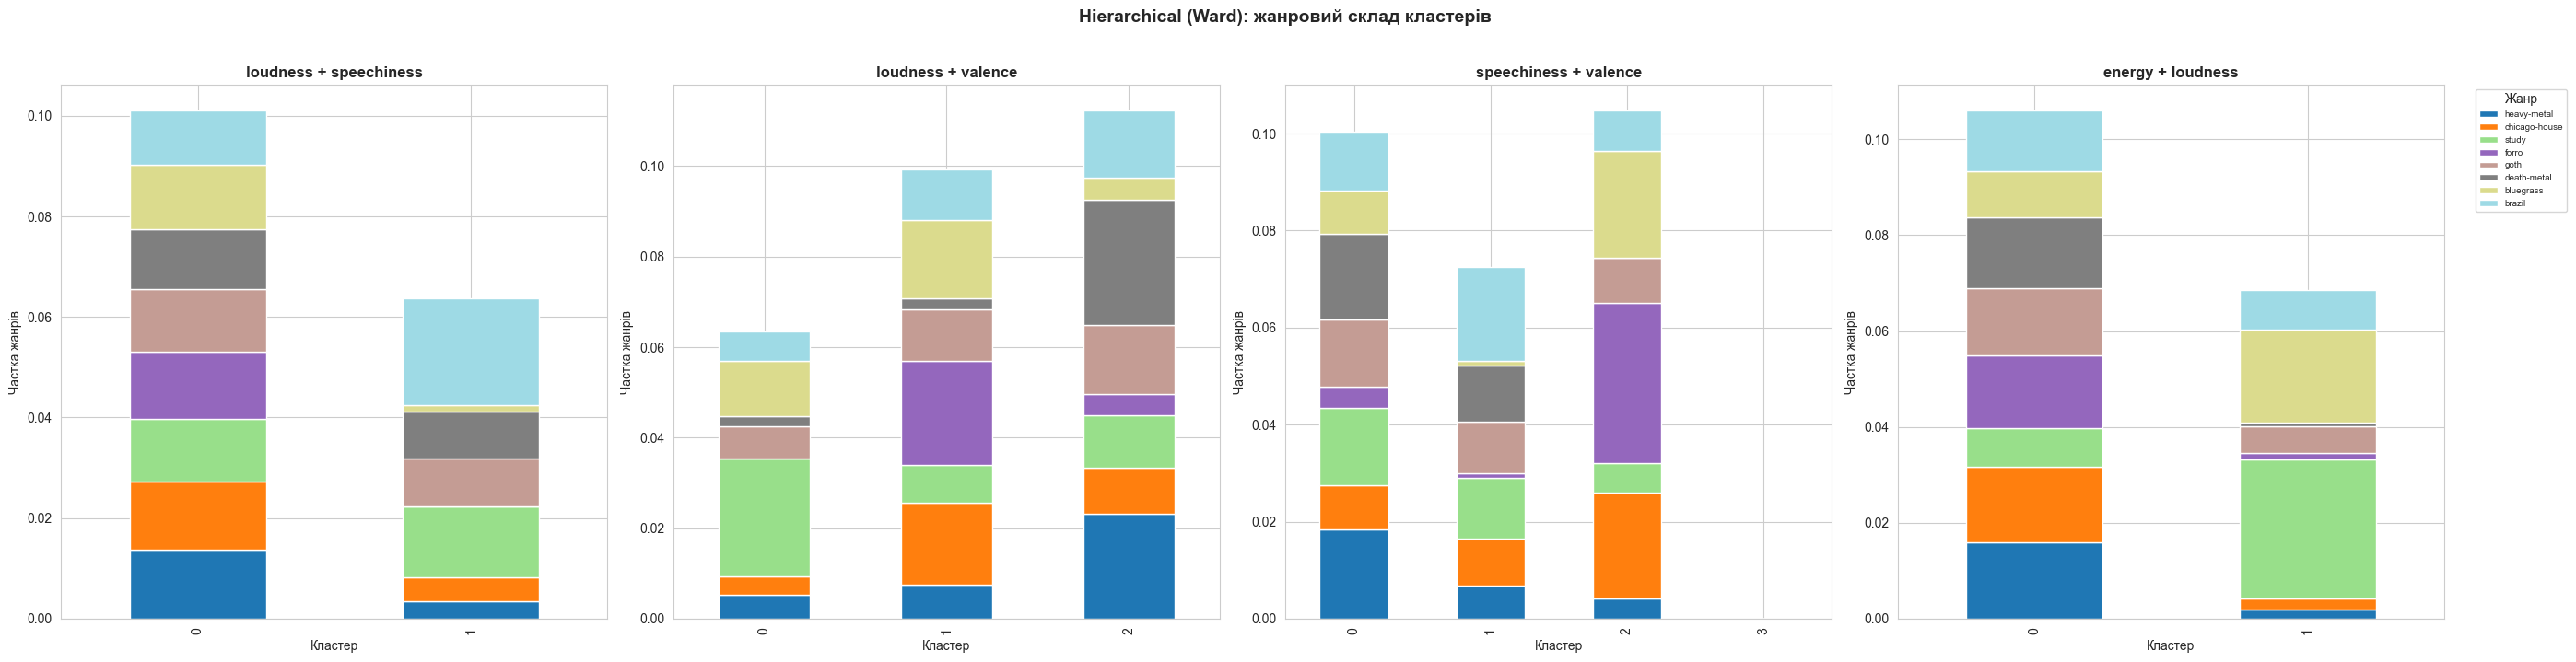

In [6]:
fig, axes = plt.subplots(1, len(pairs), figsize=(7 * len(pairs), 7))
if len(pairs) == 1:
    axes = [axes]

for i, pair in enumerate(pairs):
    df_temp = df_sub.copy()
    df_temp['cluster'] = pair_labels[i]
    top_genres = df_sub[GENRE_COL].value_counts().head(8).index
    genre_ct = pd.crosstab(df_temp['cluster'], df_temp[GENRE_COL], normalize='index')
    cols = [c for c in top_genres if c in genre_ct.columns]
    genre_ct[cols].plot(kind='bar', stacked=True, ax=axes[i], colormap='tab20', legend=False)
    axes[i].set_title(f'{pair[0]} + {pair[1]}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Кластер')
    axes[i].set_ylabel('Частка жанрiв')

axes[-1].legend(title='Жанр', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.suptitle('Hierarchical (Ward): жанровий склад кластерiв', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
save_results(results, 'results_hierarchical.csv')
pd.DataFrame(results)

Результати збережено: F:\University\Магістр\Data Mining\Lab2-Data-Mining-2026\results\results_hierarchical.csv


,algorithm,pair,k,silhouette,davies_bouldin,time_sec
0,Hierarchical,loudness + speechiness,2,0.598919,0.832792,2.3117
1,Hierarchical,loudness + valence,3,0.387955,0.850003,2.6147
2,Hierarchical,speechiness + valence,4,0.488456,0.680420,2.4842
3,Hierarchical,energy + loudness,2,0.540771,0.702690,2.8289


## Пiдсумок

- Дендрограми наочно демонструють природне групування даних та дозволяють обрати кiлькiсть кластерiв вiзуально.
- Метод Ward добре працює для компактних сферичних кластерiв, мiнiмiзуючи внутрiшньокластерну дисперсiю.
- Iєрархiчна кластеризацiя не потребує початкової iнiцiалiзацiї центрiв, що забезпечує детермiнованi результати.
- Аналiз жанрового складу пiдтверджує, що кластери мають змiстовну iнтерпретацiю.